<a href="https://colab.research.google.com/github/swagatadutta26/end-to-end-image-understanding/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -U transformers accelerate torch torchvision pillow matplotlib timm -q

In [4]:
from transformers import pipeline
from transformers import BlipProcessor
from transformers import BlipForConditionalGeneration

from PIL import Image
from google.colab import files

import matplotlib.pyplot as plt
import torch

In [5]:
device = 0 if torch.cuda.is_available() else -1

if device == 0:

    print("Running on GPU")

else:

    print("Running on CPU")


Running on GPU


In [6]:
# Image Classification Model
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224",
    device=device
)

# Object Detection Model
detector = pipeline(
    "object-detection",
    model="facebook/detr-resnet-50",
    device=device
)

# Image Captioning Model
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

caption_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

# Move caption model to GPU if available
if device == 0:

    caption_model = caption_model.to("cuda")


print("AI Models Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

AI Models Loaded Successfully


In [7]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

print("Image Uploaded Successfully")

Saving d921ce0dca361c69e9a7668130c2d033.jpg to d921ce0dca361c69e9a7668130c2d033.jpg
Image Uploaded Successfully


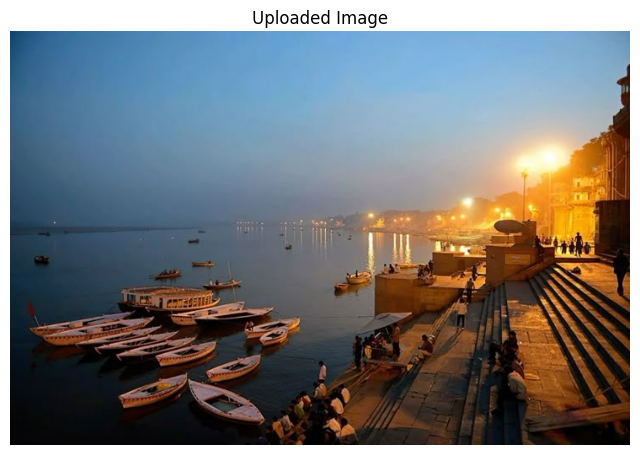

In [8]:
plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.axis("off")

plt.title("Uploaded Image")

plt.show()

In [9]:
print("IMAGE CLASSIFICATION :")

classification_results = classifier(
    image,
    top_k=5
)

for result in classification_results:

    label = result["label"]

    score = round(
        result["score"] * 100,
        2
    )

    print(f"{label} --> {score}%")

IMAGE CLASSIFICATION :
dock, dockage, docking facility --> 29.59%
lakeside, lakeshore --> 22.37%
boathouse --> 8.01%
drilling platform, offshore rig --> 7.8%
pier --> 5.33%


In [10]:
if device == 0:

    inputs = processor(
        image,
        return_tensors="pt"
    ).to("cuda")

else:

    inputs = processor(
        image,
        return_tensors="pt"
    )

output = caption_model.generate(**inputs)

generated_text = processor.decode(
    output[0],
    skip_special_tokens=True
)

print("AI GENERATED CAPTION :")

print(generated_text)

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


AI GENERATED CAPTION :
boats are docked in the water at dusk


In [11]:
objects = detector(image)

print("OBJECT DETECTION :")

detected_items = []

detection_threshold = 0.60

for obj in objects:

    label = obj["label"]

    score = round(
        obj["score"] * 100,
        2
    )

    if (
        obj["score"] >= detection_threshold
        and label not in detected_items
    ):

        detected_items.append(label)

        print(f"{label} --> {score}%")

if len(detected_items) == 0:

    print(
        "No objects detected above confidence threshold."
    )

OBJECT DETECTION :
boat --> 88.57%
person --> 88.47%
umbrella --> 93.04%


In [12]:
print("SCENE ANALYSIS :")

text = generated_text.lower()

indoor_keywords = [
    "room", "office", "garage", "hall",
    "building", "wall", "shop", "store"
]

outdoor_keywords = [
    "tree", "mountain", "river", "lake",
    "road", "sky", "grass", "nature", "forest", "ocean",
    "dock", "pier", "beach", "park", "outdoor","field", "waterfall",
    "cloud"
]

indoor_score = 0
outdoor_score = 0

for word in indoor_keywords:

    if word in text:

        indoor_score += 1

for word in outdoor_keywords:

    if word in text:

        outdoor_score += 1

if indoor_score > outdoor_score:

    scene_type = "Indoor"

elif outdoor_score > indoor_score:

    scene_type = "Outdoor"

else:

    scene_type = "Mixed / Unclear Environment"


print("Scene Type :", scene_type)

SCENE ANALYSIS :
Scene Type : Outdoor


In [13]:
print("PERSON ANALYSIS :")

lower_detected_items = []

for item in detected_items:

    lower_detected_items.append(
        item.lower()
    )

if "person" in lower_detected_items:

    person_status = "Person detected in image"

else:

    person_status = "No person detected in image"

print(person_status)

PERSON ANALYSIS :
Person detected in image


In [14]:
print("DETAILED FINAL ANALYSIS :")

print("\nGenerated Caption:")
print(generated_text)

print("\nDetected Objects:")

if len(detected_items) > 0:

    for item in detected_items:

        print("-", item)

else:

    print("- None")

print("\nScene Type:")
print(scene_type)

print("\nPerson Analysis:")
print(person_status)

print("\nTop Classification Results:")

for result in classification_results[:3]:

    print(
        f"- {result['label']} "
        f"({round(result['score'] * 100, 2)}%)"
    )

print("\nAI Final Summary:")

summary = f"""

The uploaded image has been analyzed successfully
using AI-based image classification, image captioning,
object detection, and scene analysis techniques.

The system generated the caption:

"{generated_text}"

The detected scene type is:

{scene_type}

Person Analysis:

{person_status}

The system dynamically detected objects,
generated image captions, and produced
a detailed AI-based image analysis automatically.

"""

print(summary)

print("AI IMAGE ANALYSIS COMPLETED")


DETAILED FINAL ANALYSIS :

Generated Caption:
boats are docked in the water at dusk

Detected Objects:
- boat
- person
- umbrella

Scene Type:
Outdoor

Person Analysis:
Person detected in image

Top Classification Results:
- dock, dockage, docking facility (29.59%)
- lakeside, lakeshore (22.37%)
- boathouse (8.01%)

AI Final Summary:


The uploaded image has been analyzed successfully
using AI-based image classification, image captioning,
object detection, and scene analysis techniques.

The system generated the caption:

"boats are docked in the water at dusk"

The detected scene type is:

Outdoor

Person Analysis:

Person detected in image

The system dynamically detected objects,
generated image captions, and produced
a detailed AI-based image analysis automatically.


AI IMAGE ANALYSIS COMPLETED
